# Analisi delle Serie Temporali: Precipitazioni di Londra
## 1. Setup e Importazione delle Librerie
In questa cella installiamo e importiamo tutte le librerie necessarie per l'analisi delle serie temporali, la visualizzazione dei grafici e il calcolo delle metriche di performance.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

%matplotlib inline


## 2. Caricamento Dataset e Resampling Mensile
Carichiamo il dataset, applichiamo l'interpolazione lineare per gestire i valori mancanti e impostiamo la data come indice.

Aggreghiamo i dati su base mensile (`'M'`). Per la pioggia sommiamo i millimetri totali del mese, mentre per le altre variabili esogene calcoliamo la media mensile. Questo stabilizza la serie ed elimina il problema dei troppi zeri consecutivi.

In [ ]:
# Caricamento del dataset (se usi Colab, assicurati di aver caricato il file 'london_weather.csv')
data = pd.read_csv("london_weather.csv")

# Lista delle colonne da trattare
columns_to_interpolate = [
    "cloud_cover", "global_radiation", "max_temp",
    "mean_temp", "min_temp", "precipitation", "snow_depth", "pressure"
]

# Riempire i valori mancanti tramite interpolazione lineare
for col in columns_to_interpolate:
    data[col] = data[col].interpolate(method='linear')

# Formattazione e impostazione dell'indice temporale
data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
data.set_index('date', inplace=True)

# RESAMPLING MENSILE: Somma per le piogge, media per i fattori esogeni
data_monthly = pd.DataFrame()
data_monthly['precipitation'] = data['precipitation'].resample('M').sum()
data_monthly['cloud_cover'] = data['cloud_cover'].resample('M').mean()
data_monthly['global_radiation'] = data['global_radiation'].resample('M').mean()
data_monthly['mean_temp'] = data['mean_temp'].resample('M').mean()

print("✅ Dataset campionato a frequenza MENSILE con successo.")
print(f"Numero totale di mesi: {len(data_monthly)}")
print(data_monthly.head())

✅ Dataset campionato a frequenza MENSILE con successo.
Numero totale di mesi: 504
            precipitation  cloud_cover  global_radiation  mean_temp
date                                                               
1979-01-31           59.9     5.838710         29.032258   0.616129
1979-02-28           44.0     6.303571         45.214286   2.042857
1979-03-31           94.9     5.967742         93.354839   5.587097
1979-04-30           77.6     6.133333        134.166667   8.743333
1979-05-31           87.0     5.290323        204.064516  11.490323


In [ ]:
data.isnull().sum()

,0
cloud_cover,0
sunshine,0
global_radiation,0
max_temp,0
mean_temp,0
min_temp,0
precipitation,0
pressure,0
snow_depth,0


In [ ]:
data.head()

,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
date,,,,,,,,,
1979-01-01,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1979-01-02,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
1979-01-03,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
1979-01-04,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
1979-01-05,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


TIME SERIES


## 3. Analisi della Stazionarietà (Test ADF) e Visualizzazione della Serie
Visualizziamo l'andamento storico delle precipitazioni mensili ed eseguiamo il test di Augmented Dickey-Fuller (ADF) per verificare matematicamente se la serie è stazionaria.

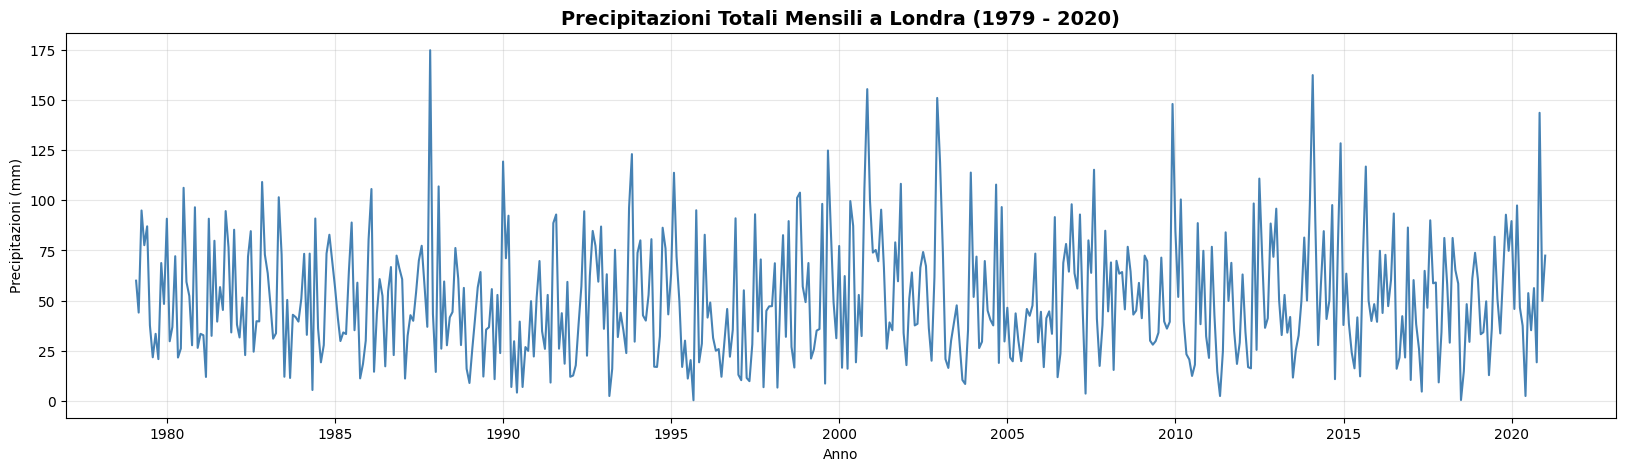

Risultati del Test di Dickey-Fuller:
Statistica del test: -20.6094
Numero di lag usati: 0
Numero di osservazioni usate: 503
P-value: 0.0000
Valori critici:
	1%: -3.4434
	5%: -2.8673
	10%: -2.5698


In [ ]:

# Grafico della serie storica mensile
plt.figure(figsize=(20, 5))
plt.plot(data_monthly.index, data_monthly['precipitation'], color='steelblue', linewidth=1.5)
plt.title('Precipitazioni Totali Mensili a Londra (1979 - 2020)', fontsize=14, fontweight='bold')
plt.xlabel('Anno')
plt.ylabel('Precipitazioni (mm)')
plt.grid(True, alpha=0.3)
plt.show()

# Esecuzione del test ADF
result = adfuller(data_monthly['precipitation'])
print("Risultati del Test di Dickey-Fuller:")
print(f"Statistica del test: {result[0]:.4f}")
print(f"Numero di lag usati: {result[2]}")
print(f"Numero di osservazioni usate: {result[3]}")
print(f"P-value: {result[1]:.4f}")
print("Valori critici:")
for key, value in result[4].items():
    print(f"\t{key}: {value:.4f}")


## 4. Analisi delle Autocorrelazioni (ACF e PACF)
Analizziamo i grafici ACF e PACF sui dati mensili per studiare la memoria della serie temporale e confermare visivamente la presenza di cicli stagionali ripetitivi.

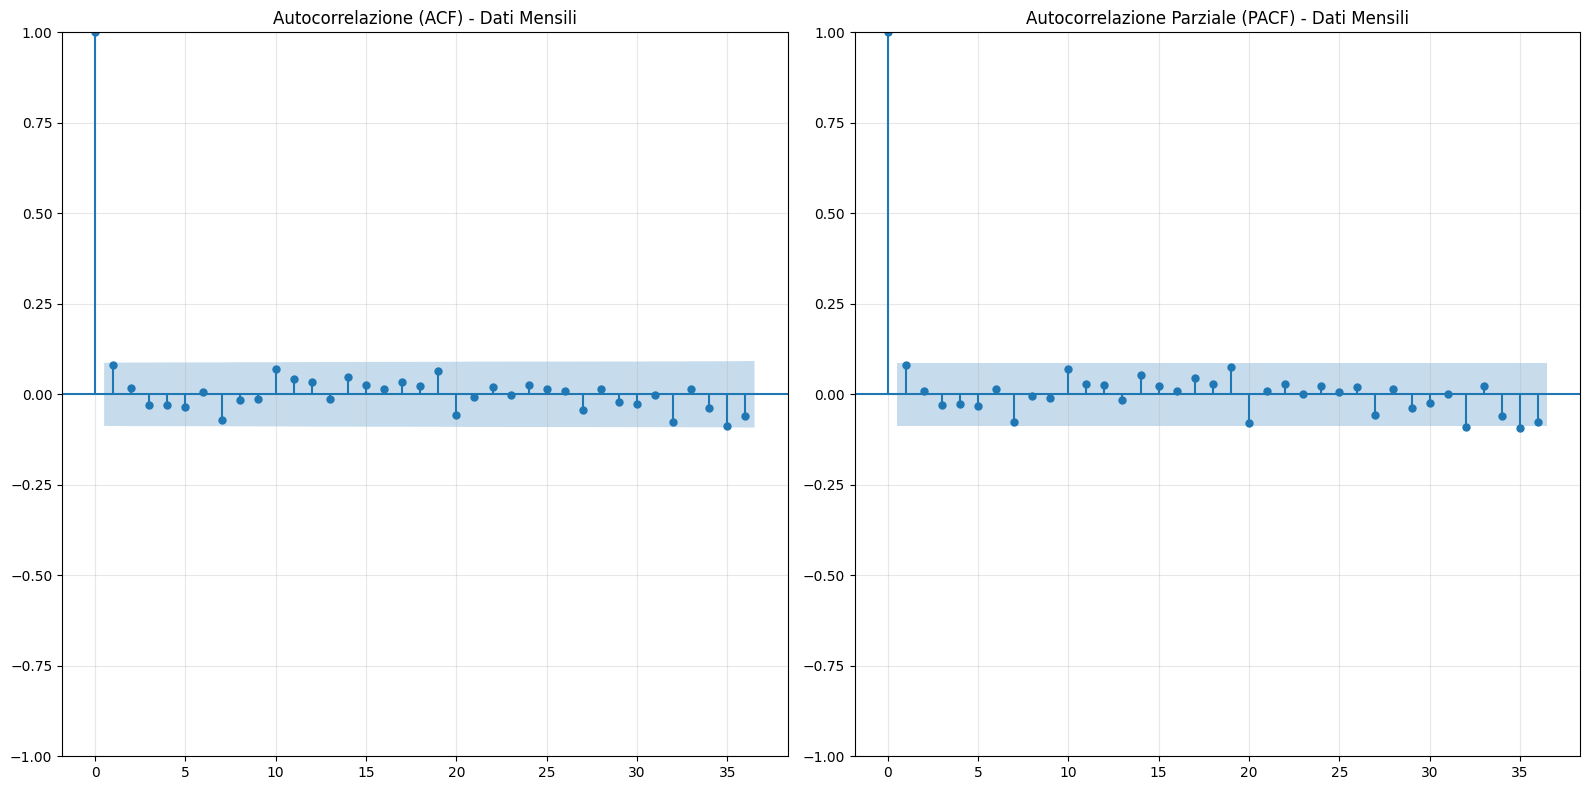

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Grafico ACF
plot_acf(data_monthly['precipitation'], lags=36, alpha=0.05, ax=axes[0], title='Autocorrelazione (ACF) - Dati Mensili')
axes[0].grid(True, alpha=0.3)

# Grafico PACF
plot_pacf(data_monthly['precipitation'], lags=36, alpha=0.05, method='ols', ax=axes[1], title='Autocorrelazione Parziale (PACF) - Dati Mensili')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Suddivisione in Train e Test Set
Dividiamo la serie mensile destinando l'85% dei dati storici all'addestramento (Training Set) e il restante 15% alla successiva fase di validazione e testing (Test Set).

In [ ]:
num_points = len(data_monthly)
train_part = int(num_points * 0.85)

train = data_monthly['precipitation'].iloc[:train_part]
test = data_monthly['precipitation'].iloc[train_part:]

print(f"Punti totali: {num_points} | Train set (mesi): {len(train)} | Test set (mesi): {len(test)}")

Punti totali: 504 | Train set (mesi): 428 | Test set (mesi): 76


## 6. Modello Baseline ARIMA(1, 0, 2)
Costruiamo e addestriamo un modello ARIMA non stagionale usando l'ordine ottimale emerso dalle tue precedenti analisi. Nel grafico, usiamo l'operatore `.clip(lower=0)` per evitare che l'intervallo di confidenza scenda sotto lo zero fisicamente impossibile.

                               SARIMAX Results                                
Dep. Variable:          precipitation   No. Observations:                  428
Model:                 ARIMA(1, 0, 2)   Log Likelihood               -2060.521
Date:                Tue, 16 Jun 2026   AIC                           4131.041
Time:                        14:40:57   BIC                           4151.337
Sample:                    01-31-1979   HQIC                          4139.057
                         - 08-31-2014                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         50.7803      1.852     27.425      0.000      47.151      54.409
ar.L1         -0.8503      0.444     -1.915      0.055      -1.720       0.020
ma.L1          0.9501      0.441      2.153      0.0

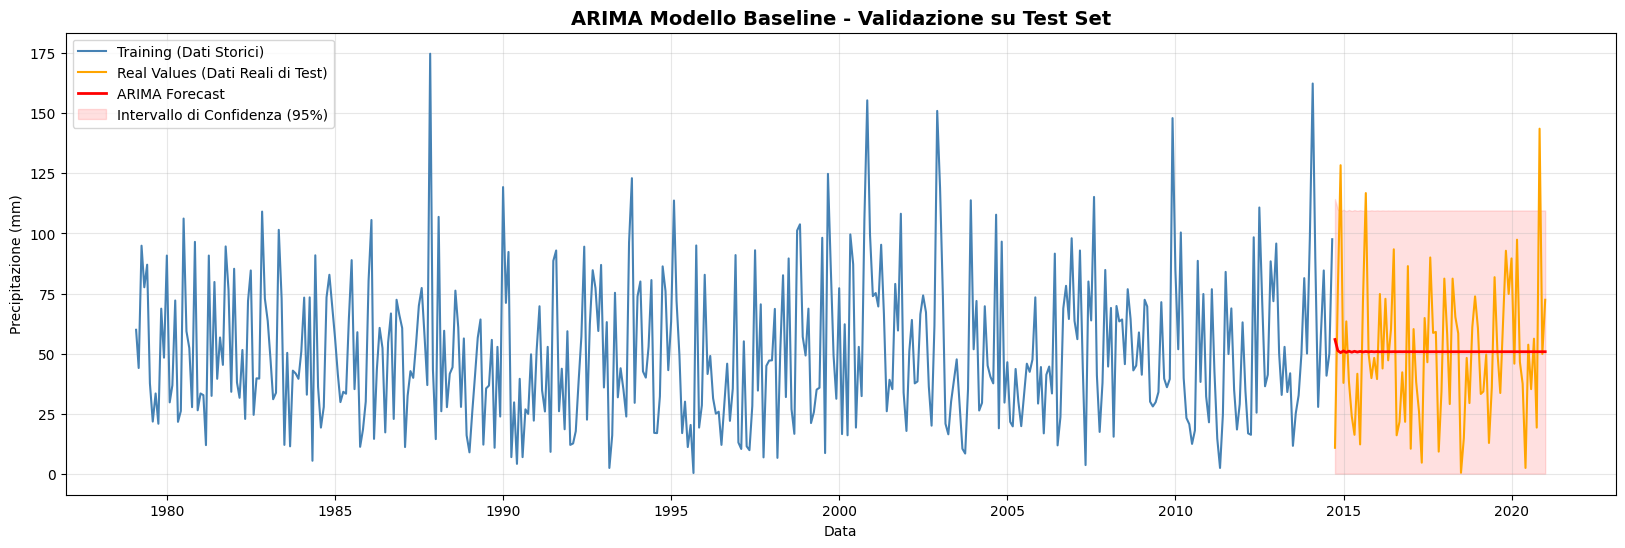

In [ ]:
# Configurazione e fitting del modello ARIMA
arima_model = ARIMA(train, order=(1, 0, 2))
arima_results = arima_model.fit()
print(arima_results.summary())

# Generazione delle previsioni sul test set con intervalli di confidenza
forecast_results = arima_results.get_forecast(steps=len(test))
conf_int = forecast_results.conf_int(alpha=0.05)
fc = forecast_results.predicted_mean

# Correzione fisica dei limiti inferiori negativi
lower_series = conf_int.iloc[:, 0].clip(lower=0)
upper_series = conf_int.iloc[:, 1]
fc_cleaned = fc.clip(lower=0)

# Grafico di validazione ARIMA
plt.figure(figsize=(20, 6), dpi=100)
plt.plot(train, label="Training (Dati Storici)", color='steelblue')
plt.plot(test, label="Real Values (Dati Reali di Test)", color='orange')
plt.plot(fc_cleaned, label="ARIMA Forecast", color='red', linewidth=2)
plt.fill_between(lower_series.index, lower_series, upper_series, color='red', alpha=0.12, label="Intervallo di Confidenza (95%)")
plt.title("ARIMA Modello Baseline - Validazione su Test Set", fontsize=14, fontweight='bold')
plt.xlabel('Data')
plt.ylabel('Precipitazione (mm)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()


## 7. Modello SARIMAX con Variabili Esogene e Stagionalità S=12
Implementiamo il modello SARIMAX avanzato. Sfruttando la frequenza mensile, impostiamo la vera stagionalità annuale a `s=12`. Inoltre, forniamo al modello le variabili esogene (`cloud_cover`, `global_radiation`, `mean_temp`) sia in fase di addestramento che in fase di previsione futura.

                                     SARIMAX Results                                      
Dep. Variable:                      precipitation   No. Observations:                  428
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 12)   Log Likelihood               -1914.062
Date:                            Tue, 16 Jun 2026   AIC                           3842.125
Time:                                    14:52:53   BIC                           3870.100
Sample:                                01-31-1979   HQIC                          3853.201
                                     - 08-31-2014                                         
Covariance Type:                              opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
cloud_cover          7.9807      2.977      2.680      0.007       2.145      13.816
global_radiation 

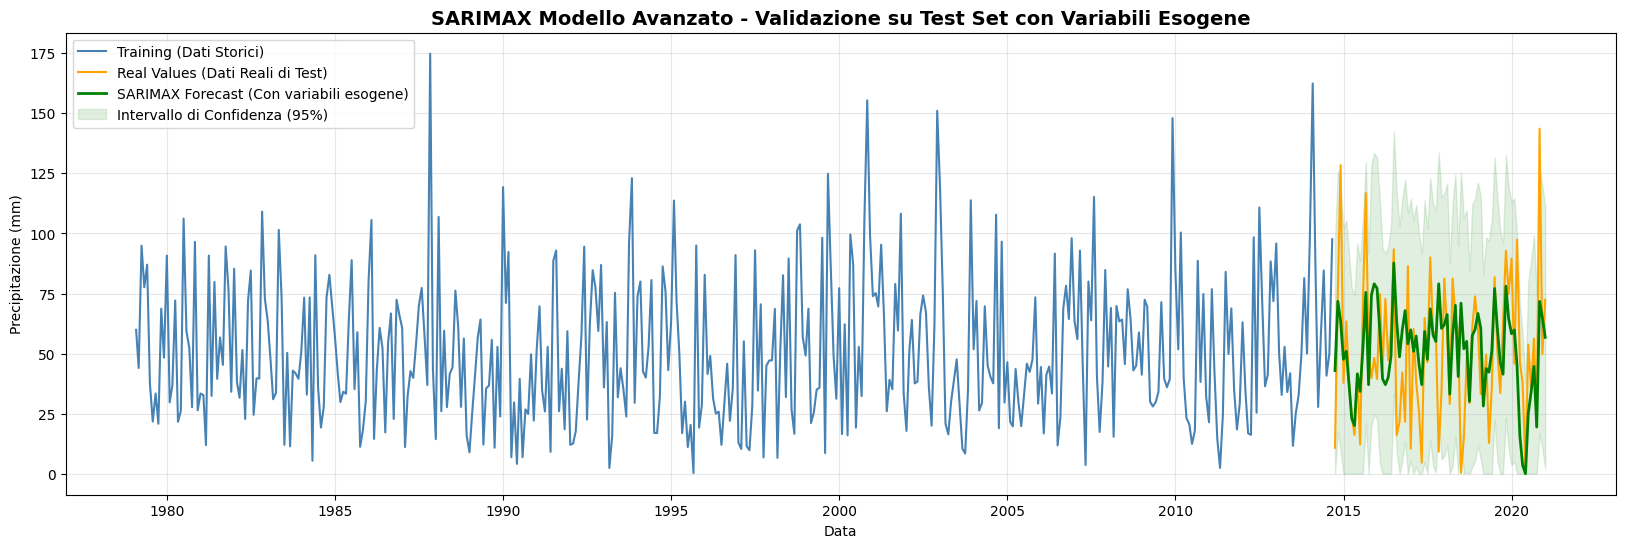

In [ ]:
# Definizione delle colonne esogene
exog_cols = ['cloud_cover', 'global_radiation', 'mean_temp']

exog_train = data_monthly[exog_cols].iloc[:train_part]
exog_test = data_monthly[exog_cols].iloc[train_part:]

# Costruzione del modello SARIMAX
sarimax_model = SARIMAX(train,
                        exog=exog_train,
                        order=(1, 0, 1),
                        seasonal_order=(0, 1, 1, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False)

sarimax_results = sarimax_model.fit(disp=False)
print(sarimax_results.summary())

# Forecasting sul test set passando i dati esogeni di test futuri
sarimax_forecast = sarimax_results.get_forecast(steps=len(test), exog=exog_test)
sarimax_fc = sarimax_forecast.predicted_mean.clip(lower=0)
sarimax_ci = sarimax_forecast.conf_int(alpha=0.05)

sarimax_lower = sarimax_ci.iloc[:, 0].clip(lower=0)
sarimax_upper = sarimax_ci.iloc[:, 1]

# Grafico di validazione SARIMAX
plt.figure(figsize=(20, 6), dpi=100)
plt.plot(train, label="Training (Dati Storici)", color='steelblue')
plt.plot(test, label="Real Values (Dati Reali di Test)", color='orange')
plt.plot(sarimax_fc, label="SARIMAX Forecast (Con variabili esogene)", color='green', linewidth=2)
plt.fill_between(sarimax_lower.index, sarimax_lower, sarimax_upper, color='green', alpha=0.12, label="Intervallo di Confidenza (95%)")
plt.title("SARIMAX Modello Avanzato - Validazione su Test Set con Variabili Esogene", fontsize=14, fontweight='bold')
plt.xlabel('Data')
plt.ylabel('Precipitazione (mm)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

## 8. Analisi dei Residui del Modello SARIMAX
Verifichiamo la bontà del modello analizzando i residui estratti. Un buon modello deve produrre residui simili ad un rumore bianco, distribuiti intorno allo zero.

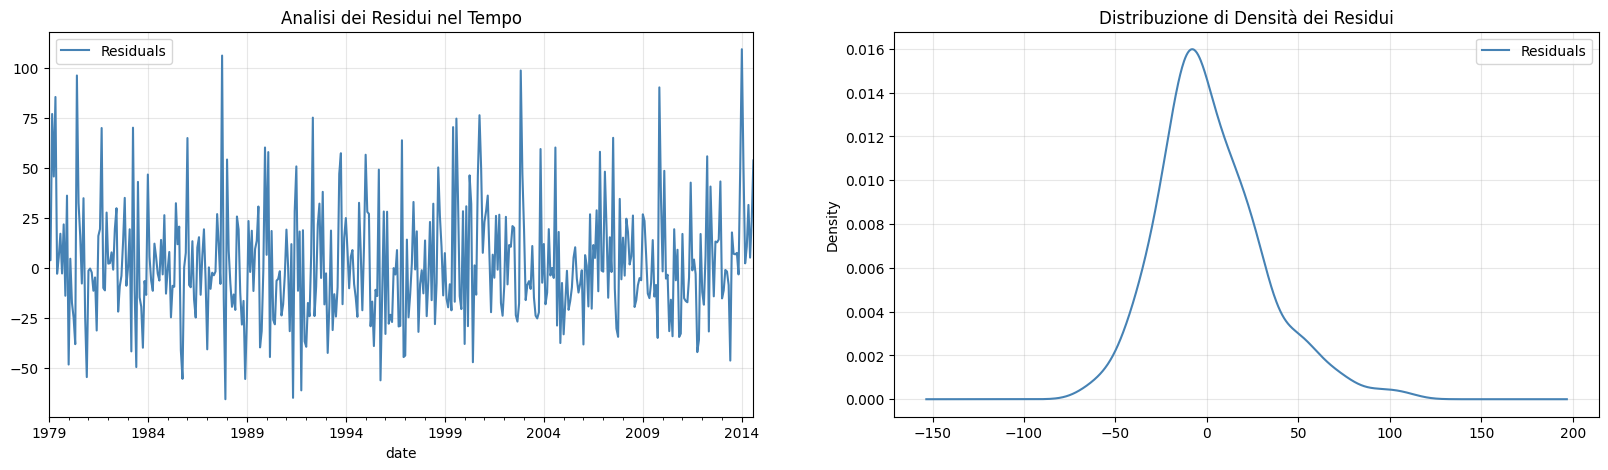

In [ ]:
# Calcolo ed estrazione dei residui
residuals = pd.DataFrame(sarimax_results.resid, columns=["Residuals"])

fig, ax = plt.subplots(1, 2, figsize=(20, 5))
residuals.plot(title="Analisi dei Residui nel Tempo", ax=ax[0], color='steelblue')
ax[0].grid(True, alpha=0.3)

residuals.plot(kind="kde", title="Distribuzione di Densità dei Residui", ax=ax[1], color='steelblue')
ax[1].grid(True, alpha=0.3)

plt.show()

## 9. Calcolo delle Metriche di Errore ed Evaluation Finali
In quest'ultima cella calcoliamo le metriche di errore fondamentali per validare numericamente le performance predittive del modello SARIMAX sui dati mensili aggregati.

In [ ]:
# Calcolo degli errori
errors = test - sarimax_fc

rmse = np.sqrt(mean_squared_error(test, sarimax_fc))
mae = mean_absolute_error(test, sarimax_fc)
me = np.mean(errors)
correlation = np.corrcoef(test, sarimax_fc)[0, 1]
mape = np.mean(np.abs(errors / test)) * 100

print("--- METRICHE DI VALUTAZIONE FINALI (SARIMAX MENSILE) ---")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"MAE (Mean Absolute Error):     {mae:.4f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
print(f"ME (Mean Error):               {me:.4f}")
print(f"Correlazione Lineare (R):      {correlation:.4f}")

print("\n✅ Analisi delle serie temporali completata con successo.")

--- METRICHE DI VALUTAZIONE FINALI (SARIMAX MENSILE) ---
RMSE (Root Mean Squared Error): 26.6759
MAE (Mean Absolute Error):     20.0123
MAPE (Mean Absolute Percentage Error): 304.17%
ME (Mean Error):               -0.7677
Correlazione Lineare (R):      0.4259

✅ Analisi delle serie temporali completata con successo.
